# Notebook para treinamento e testes de modelos

In [1]:
import pandas as pd
import numpy as np

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.exponential_smoothing.ets import ETSModel

from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
import datetime
from dateutil.relativedelta import relativedelta
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import optuna

c:\Users\jhiy2\Documents\trabalho_icd\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Leitura da base de dados

In [2]:
# Base fipe historica
fipe_path = './data/dados_fipe_tratados.csv'
# Base da taxa de cambio
exchange_path = './data/DEXBZUS_tratados.csv'
# Base IPCA
ipca_path = './data/bcdata.sgs.433_tratados.csv' 

df_fipe = pd.read_csv(fipe_path)
print('FIPE shape:', df_fipe.shape)
print(df_fipe.head())

df_ex = pd.read_csv(exchange_path)
print('DEXBZUS head:')
print(df_ex.head())

df_ipca = pd.read_csv(ipca_path)
print('IPCA head:')
print(df_ipca.head())

FIPE shape: (411498, 9)
   Unnamed: 0       reference_date brand_name          model_name  year  \
0           0  2021-01-01 00:00:00       Fiat           147 C/ CL  1987   
1           1  2021-01-01 00:00:00       Fiat           147 C/ CL  1986   
2           2  2021-01-01 00:00:00       Fiat           147 C/ CL  1985   
3           3  2021-01-01 00:00:00       Fiat  147 Furgão (todos)  1987   
4           4  2021-01-01 00:00:00       Fiat  147 Furgão (todos)  1986   

  fuel_name  brl_price  year_of_reference month_of_reference  
0  Gasolina     2723.0               2021            January  
1  Gasolina     2484.0               2021            January  
2  Gasolina     2324.0               2021            January  
3  Gasolina     2199.0               2021            January  
4  Gasolina     2094.0               2021            January  
DEXBZUS head:
         date  exchange_rate
0  1995-01-01       0.846091
1  1995-02-01       0.841150
2  1995-03-01       0.890522
3  1995-04-01    

In [3]:
df_ipca['date'] = pd.to_datetime(df_ipca['date'])
df_ex['date'] = pd.to_datetime(df_ex['date'])

df_ipca.index = df_ipca['date']
df_ex.index = df_ex['date']

In [4]:
df_fipe = df_fipe.drop(columns=['Unnamed: 0'])

In [5]:
df_fipe['reference_date'] = pd.to_datetime(df_fipe['reference_date'], format='ISO8601')

In [6]:
df_fipe = df_fipe[df_fipe['reference_date'].dt.year > 2022]

In [7]:
df_fipe.head()

,reference_date,brand_name,model_name,year,fuel_name,brl_price,year_of_reference,month_of_reference
125101,2023-09-01,Fiat,147 C/ CL,1987,Gasolina,4630.0,2023,September
125102,2023-09-01,Fiat,147 C/ CL,1986,Gasolina,4478.0,2023,September
125103,2023-09-01,Fiat,147 C/ CL,1985,Gasolina,3898.0,2023,September
125104,2023-09-01,Fiat,147 Furgão (todos),1987,Gasolina,2637.0,2023,September
125105,2023-09-01,Fiat,147 Furgão (todos),1986,Gasolina,2528.0,2023,September


In [8]:
df_fipe = df_fipe.drop(columns=['year_of_reference', 'month_of_reference'])

In [9]:
df_celta = df_fipe[(df_fipe['model_name'].str.startswith('Celta Super 1.0 MPFI 8V FlexPower 5p')) & (df_fipe['year'] == 2008) & (df_fipe['fuel_name'] == 'Flex')]

In [10]:
df_celta.shape

(38, 6)

In [11]:
df_celta.index = df_celta['reference_date']

In [12]:
df_celta = df_celta.sort_index()

In [13]:
df_celta[df_celta['reference_date'].dt.year == 2026]

,reference_date,brand_name,model_name,year,fuel_name,brl_price
reference_date,,,,,,
2026-01-01,2026-01-01,GM - Chevrolet,Celta Super 1.0 MPFI 8V FlexPower 5p,2008,Flex,21226.0
2026-02-01,2026-02-01,GM - Chevrolet,Celta Super 1.0 MPFI 8V FlexPower 5p,2008,Flex,21119.0
2026-03-01,2026-03-01,GM - Chevrolet,Celta Super 1.0 MPFI 8V FlexPower 5p,2008,Flex,22174.0
2026-04-01,2026-04-01,GM - Chevrolet,Celta Super 1.0 MPFI 8V FlexPower 5p,2008,Flex,22862.0


In [14]:
df_fipe.columns

Index(['reference_date', 'brand_name', 'model_name', 'year', 'fuel_name',
       'brl_price'],
      dtype='str')

In [15]:
# garantir que a data seja o índice
df = df_celta.copy()
df = df.set_index('reference_date')

# índice completo de meses
meses_esperados = pd.date_range('2023-01', '2026-04', freq='MS')

# adiciona os meses faltantes
df = df.reindex(meses_esperados)

# preencher colunas fixas
df['brand_name'] = df['brand_name'].ffill()
df['model_name'] = df['model_name'].ffill()
df['year'] = df['year'].ffill()
df['fuel_name'] = df['fuel_name'].ffill()

# imputar preço
df['brl_price'] = df['brl_price'].interpolate(method='linear')

# voltar a coluna de data
df = df.rename_axis('reference_date').reset_index()

df.index = df['reference_date']

Text(0, 0.5, 'Preço médio (R$)')

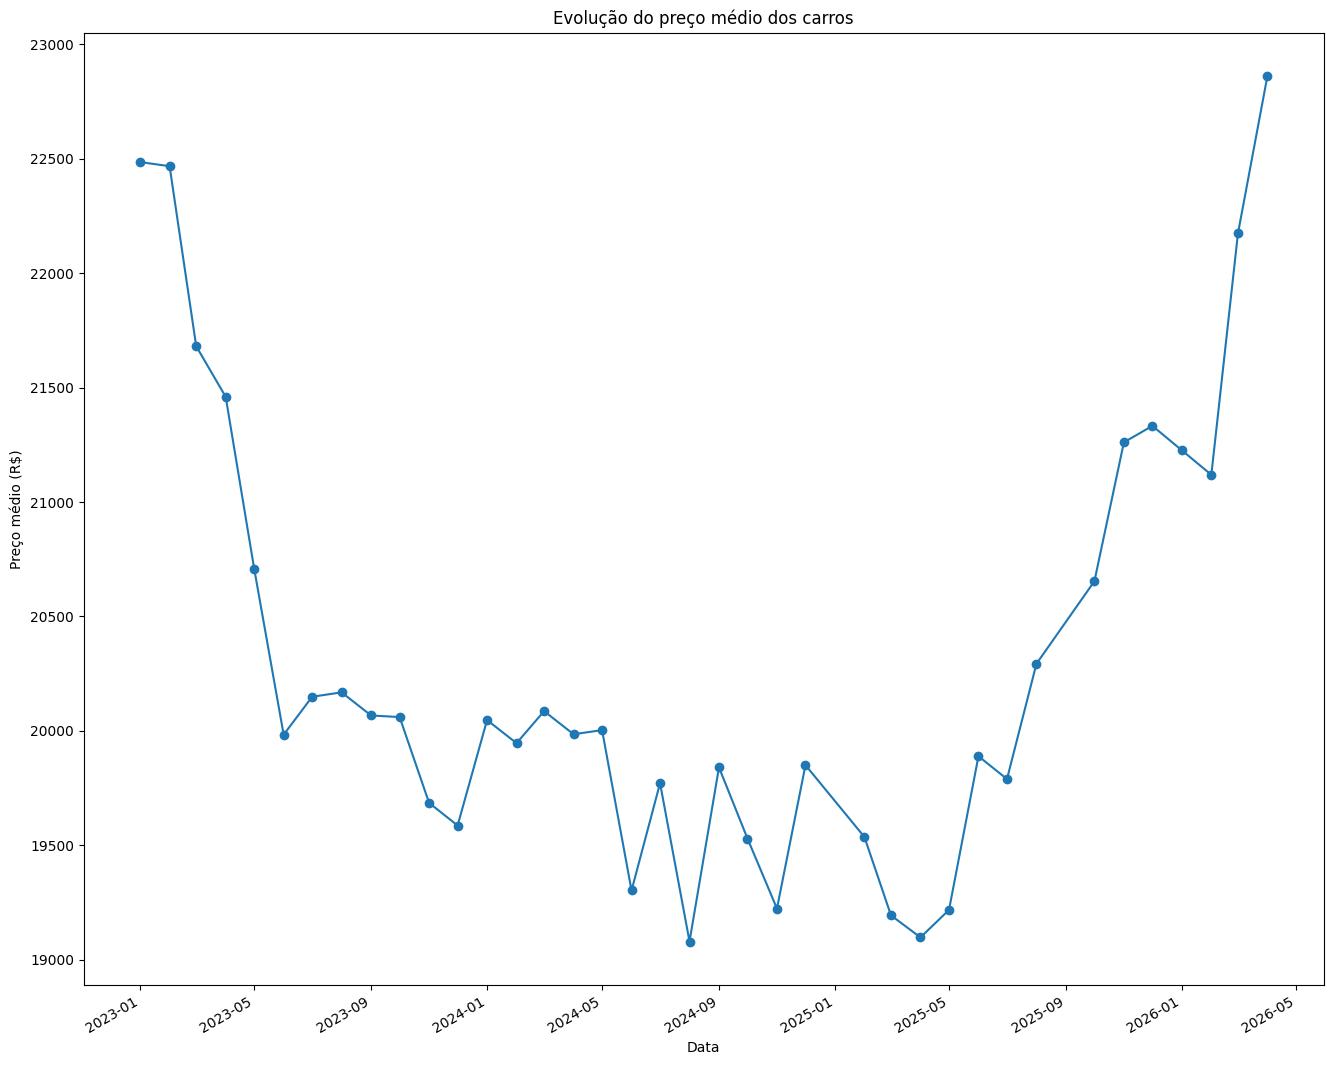

In [16]:
fig, ax = plt.subplots(figsize=(16, 14))

df_celta['brl_price'].plot(marker='o', ax=ax)
ax.set_title('Evolução do preço médio dos carros')
ax.set_xlabel('Data')
ax.set_ylabel('Preço médio (R$)')

## Separar os dados em treino e teste

In [17]:
data_ref = datetime.datetime(2026, 4, 1)
start = data_ref - relativedelta(months=6)

train = df[
    df['reference_date'] <= start
]
test = df[
    df['reference_date'] > start
]

train_ipca = df_ipca[
    df_ipca['date'].isin(train['reference_date'])
]

test_ipca = df_ipca[
    df_ipca['date'].isin(test['reference_date'])
]

train_ex = df_ex[
    df_ex['date'].isin(train['reference_date'])
]

test_ex = df_ex[
    df_ex['date'].isin(test['reference_date'])
]

exog_train = pd.concat([train_ipca['valor'], train_ex['exchange_rate']], axis=1)
exog_test = pd.concat([test_ipca['valor'], test_ex['exchange_rate']], axis=1)

In [18]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
optuna.logging.set_verbosity(optuna.logging.ERROR)

## Geradores de modelos SARIMAX e ETS

In [19]:
from model_generators import generate_ets_model, generate_sarimax_model, generate_prophet_model, feature_engineering

Importing plotly failed. Interactive plots will not work.


## Teste dos modelos

### ETS

In [20]:
model, _, best_value = generate_ets_model(train['brl_price'], test['brl_price'], 1, 'mae', 200)

results = model.fit(disp=False)

  0%|          | 0/1 [00:00<?, ?it/s]c:\Users\jhiy2\Documents\trabalho_icd\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
Best trial: 0. Best value: 853.808: 100%|██████████| 1/1 [00:00<00:00, 33.19it/s]
c:\Users\jhiy2\Documents\trabalho_icd\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [21]:
forecast = results.forecast(steps=len(test))
forecast.index = test.index

print(best_value)
print(forecast)

853.8084771177578
reference_date
2025-11-01    20564.728392
2025-12-01    20561.885947
2026-01-01    20559.421223
2026-02-01    20557.283989
2026-03-01    20555.430704
2026-04-01    20553.823622
Name: simulation, dtype: float64


In [22]:
pd.concat([forecast, test['brl_price']], axis=1)

,simulation,brl_price
reference_date,,
2025-11-01,20564.728392,21261.0
2025-12-01,20561.885947,21333.0
2026-01-01,20559.421223,21226.0
2026-02-01,20557.283989,21119.0
2026-03-01,20555.430704,22174.0
2026-04-01,20553.823622,22862.0


### SARIMAX

In [23]:
model, _, best_value = generate_sarimax_model(train['brl_price'], test['brl_price'], exog_train, exog_test, 1, 'mape', 0.01)

results = model.fit(disp=False)

  0%|          | 0/1 [00:00<?, ?it/s]c:\Users\jhiy2\Documents\trabalho_icd\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\jhiy2\Documents\trabalho_icd\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\jhiy2\Documents\trabalho_icd\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\jhiy2\Documents\trabalho_icd\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maxi

In [24]:
forecast = results.forecast(steps=len(test), exog=exog_test)
forecast.index = test.index

print(best_value)
print(forecast)

0.014374261058010318
reference_date
2025-11-01    21126.348956
2025-12-01    21060.903198
2026-01-01    21433.398784
2026-02-01    22014.936896
2026-03-01    22512.809065
2026-04-01    22789.447033
Name: predicted_mean, dtype: float64


In [25]:
pd.concat([forecast, test['brl_price']], axis=1)

,predicted_mean,brl_price
reference_date,,
2025-11-01,21126.348956,21261.0
2025-12-01,21060.903198,21333.0
2026-01-01,21433.398784,21226.0
2026-02-01,22014.936896,21119.0
2026-03-01,22512.809065,22174.0
2026-04-01,22789.447033,22862.0


### Prophet

#### Adaptar dataframe para o Prophet

In [26]:
df_prophet = pd.concat([df, df_ipca, df_ex], axis=1, sort=False)
df_prophet = df_prophet[['reference_date', 'brl_price', 'valor', 'exchange_rate']]
df_prophet = df_prophet.rename(columns={
    'reference_date': 'ds',
    'brl_price': 'y'
})

#new_features = feature_engineering(df_prophet, 'y')

data_ref = datetime.datetime(2026, 4, 1)
start = data_ref - relativedelta(months=6)

df_train_prophet = df_prophet[
    df_prophet['ds'] <= start
]
df_test_prophet = df_prophet[
    df_prophet['ds'] > start
]

df_train_prophet = df_train_prophet.reset_index(drop=True)
df_test_prophet = df_test_prophet.reset_index(drop=True)

#### Modelo do Câmbio

In [27]:
df_train_exchange = df_train_prophet[['ds', 'exchange_rate']].rename(columns={'exchange_rate': 'y'})
df_test_exchange = df_test_prophet[['ds', 'exchange_rate']].rename(columns={'exchange_rate': 'y'})

model_exchange, info_exchange, best_value_exchange = generate_prophet_model(
    df_train_exchange,
    df_test_exchange,
    [],
    100,
    'mae',
    0.01
)

model_exchange.fit(
    df_train_exchange,
)

forecast_exchange = model_exchange.predict(
    df_test_exchange[['ds']]
)

pd.concat([df_test_exchange['y'], forecast_exchange['yhat']], axis=1)


  0%|          | 0/100 [00:00<?, ?it/s]18:57:26 - cmdstanpy - INFO - Chain [1] start processing
18:57:26 - cmdstanpy - INFO - Chain [1] done processing
Best trial: 0. Best value: 0.114822:   1%|          | 1/100 [00:00<00:22,  4.37it/s]18:57:26 - cmdstanpy - INFO - Chain [1] start processing
18:57:26 - cmdstanpy - INFO - Chain [1] done processing
Best trial: 0. Best value: 0.114822:   2%|▏         | 2/100 [00:00<00:21,  4.59it/s]18:57:26 - cmdstanpy - INFO - Chain [1] start processing
18:57:26 - cmdstanpy - INFO - Chain [1] done processing
Best trial: 0. Best value: 0.114822:   3%|▎         | 3/100 [00:00<00:20,  4.82it/s]18:57:26 - cmdstanpy - INFO - Chain [1] start processing
18:57:26 - cmdstanpy - INFO - Chain [1] done processing
Best trial: 0. Best value: 0.114822:   4%|▍         | 4/100 [00:00<00:19,  4.98it/s]18:57:26 - cmdstanpy - INFO - Chain [1] start processing
18:57:27 - cmdstanpy - INFO - Chain [1] done processing
Best trial: 0. Best value: 0.114822:   5%|▌         | 5/100 

,y,yhat
0,5.341483,5.339986
1,5.455709,5.492409
2,5.331620,5.379123
3,5.198805,5.191134
4,5.229641,5.182230
5,5.033945,5.036422


#### Modelo do IPCA

In [ ]:
df_train_ipca = df_train_prophet[['ds', 'valor']].rename(columns={'valor': 'y'})
df_test_ipca = df_test_prophet[['ds', 'valor']].rename(columns={'valor': 'y'})

model_ipca, info_ipca, best_value_ipca = generate_prophet_model(
    df_train_ipca,
    df_test_ipca,
    [],
    100,
    'mae',
    0.01
)

model_ipca.fit(
    df_train_ipca
)

forecast_ipca = model_ipca.predict(
    df_test_ipca[['ds']]
)

pd.concat([df_test_ipca['y'], forecast_ipca['yhat']], axis=1)

  0%|          | 0/100 [00:00<?, ?it/s]19:02:27 - cmdstanpy - INFO - Chain [1] start processing
19:02:27 - cmdstanpy - INFO - Chain [1] done processing
Best trial: 0. Best value: 0.342284:   1%|          | 1/100 [00:00<00:26,  3.77it/s]19:02:27 - cmdstanpy - INFO - Chain [1] start processing
19:02:27 - cmdstanpy - INFO - Chain [1] done processing
Best trial: 1. Best value: 0.236179:   2%|▏         | 2/100 [00:00<00:20,  4.67it/s]19:02:27 - cmdstanpy - INFO - Chain [1] start processing
19:02:27 - cmdstanpy - INFO - Chain [1] done processing
Best trial: 1. Best value: 0.236179:   3%|▎         | 3/100 [00:00<00:19,  5.00it/s]19:02:27 - cmdstanpy - INFO - Chain [1] start processing
19:02:27 - cmdstanpy - INFO - Chain [1] done processing
Best trial: 1. Best value: 0.236179:   4%|▍         | 4/100 [00:00<00:18,  5.25it/s]19:02:28 - cmdstanpy - INFO - Chain [1] start processing
19:02:28 - cmdstanpy - INFO - Chain [1] done processing
Best trial: 1. Best value: 0.236179:   5%|▌         | 5/100 

,y,yhat
0,0.18,0.352216
1,0.33,0.548855
2,0.33,0.329959
3,0.70,1.148081
4,0.88,0.583210
5,0.67,0.537112


#### Modelo da FIPE

In [29]:
exog = ['valor', 'exchange_rate']

model_fipe, info_fipe, best_value_fipe = generate_prophet_model(
    df_train_prophet,
    df_test_prophet,
    exog,
    100,
    'mae',
    200
)

model_fipe.fit(
    df_train_prophet
)

forecast_fipe = model_fipe.predict(
    pd.concat([df_test_prophet['ds'], forecast_ipca['yhat'], forecast_exchange['yhat']], axis=1)
)
pd.concat([df_test_prophet['y'], forecast_fipe['yhat']], axis=1)


  0%|          | 0/100 [00:00<?, ?it/s]19:02:49 - cmdstanpy - INFO - Chain [1] start processing
19:02:49 - cmdstanpy - INFO - Chain [1] done processing
Best trial: 0. Best value: 705.354:   1%|          | 1/100 [00:00<00:19,  4.98it/s]19:02:49 - cmdstanpy - INFO - Chain [1] start processing
19:02:49 - cmdstanpy - INFO - Chain [1] done processing
Best trial: 0. Best value: 705.354:   2%|▏         | 2/100 [00:00<00:16,  5.97it/s]19:02:49 - cmdstanpy - INFO - Chain [1] start processing
19:02:49 - cmdstanpy - INFO - Chain [1] done processing
Best trial: 0. Best value: 705.354:   3%|▎         | 3/100 [00:00<00:17,  5.68it/s]19:02:49 - cmdstanpy - INFO - Chain [1] start processing
19:02:49 - cmdstanpy - INFO - Chain [1] done processing
Best trial: 0. Best value: 705.354:   4%|▍         | 4/100 [00:00<00:17,  5.63it/s]19:02:49 - cmdstanpy - INFO - Chain [1] start processing
19:02:50 - cmdstanpy - INFO - Chain [1] done processing
Best trial: 4. Best value: 525.709:   5%|▌         | 5/100 [00:0

,y,yhat
0,21261.0,20555.672671
1,21333.0,21049.155314
2,21226.0,21570.709660
3,21119.0,21994.810127
4,22174.0,22153.521866
5,22862.0,22631.980700
